# FIFA Players: Investigating Skill, Age, and Cost
Your role and mission: 
Imagine that **you are builidng a FIFA team on a limited budget**.
Your goal is to develop an **evidence-based strategy for choosing the type of player you spend money on**.

The data include each player's age, overall rating, twenty-nine individual skill attributes, transfer value, and weekly wage.

**Your questions:** 
What would you like to investigate to help you spend your budget well? 
Briefly explain why each question could be useful. You might consider overall rating, age, individual skills, transfer value, weekly wage, or relationships among these attributes.

# Where the data comes from

The data were originally scraped from the **FIFA 2018-2019 video game** and compiled into a public soccer database. Each row describes one player as the game rated them during that season. For this module, the data have been cleaned and prepared so that you can begin investigating immediately. **These ratings are assigned by the game, not measured on a field.** They reflect how a group of scouts and designers choose to describe each player. They are a reasonable place to practice an investigation, and they are exactly the right data for decisions inside the game, but they are not a record of what any player actually did in a match.

## 1. Load the player data
The code below imports the helper functions prepared for this activity and loads the player file from the `data` folder. You do not need to understand the internal programming details. Focus on the function name, the information inside the parentheses, and the result returned by the function. Here, `load_player_data(...)` reads the file and performs routine preparation so the data is ready for investigation.

In [ ]:
%pip install -r packages.txt
from tool_library import *

players = load_player_data("data/soccer_players.csv")
players.head()

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'
Note: you may need to restart the kernel to use updated packages.


,name,age,age_group,overall_rating,rating_group,main_position,positions,value_euro,wage_euro,weight_kgs,nationality,preferred_foot,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,freekick_accuracy,long_passing,ball_control,acceleration,sprint_speed,agility,reactions,balance,shot_power,jumping,stamina,strength,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,L. Messi,31,29 and over,94,75 and over,CF,"CF,RW,ST",110500000.0,565000.0,72.1,Argentina,Left,86,95,70,92,86,97,93,94,89,96,91,86,93,95,95,85,68,72,66,94,48,22,94,94,75,96,33,28,26
1,C. Eriksen,27,24 to 28,88,75 and over,CAM,"CAM,RM,CM",69500000.0,205000.0,76.2,Denmark,Right,88,81,52,91,80,84,86,87,89,91,76,73,80,88,81,84,50,92,58,89,46,56,84,91,67,88,59,57,22
2,P. Pogba,25,24 to 28,88,75 and over,CM,"CM,CAM",73000000.0,255000.0,83.9,France,Right,80,75,75,86,85,87,85,82,90,90,71,79,76,82,66,90,83,88,87,82,78,64,82,88,82,87,63,67,67
3,L. Insigne,27,24 to 28,88,75 and over,LW,"LW,ST",62000000.0,165000.0,59.0,Italy,Right,86,77,56,85,74,90,87,77,78,93,94,86,94,83,93,75,53,75,44,84,34,26,83,87,61,83,51,24,22
4,K. Koulibaly,27,24 to 28,88,75 and over,CB,CB,60000000.0,135000.0,88.9,Senegal,Right,30,22,83,68,14,69,28,28,60,63,70,75,50,82,40,55,81,75,94,15,87,88,24,49,33,80,91,88,87


### Examine the output
The displayed rows provide a first look at the data. Each row represents one player. Notice the rating, age, position, cost, and skill columns. 

**name** (text): the player's name\
**age** (number): age in years\
**overall_rating** (number): the game's single summary rating for the player\
**positions** (categorical): the positions the player can play\
**value_euro** (number): the transfer value the game assigns to the player\
**wage_euro** (number): the player's weekly wage in the game\
**twenty-nine skill columns** (numbers): individual attributes such as  `sprint_speed`, `composure`, `interceptions`, and `finishing`\
**age_group**\
**rating_group** (categorical): labels added during preparation  that you will use later to compare similar players

**Question:** What information in these rows seems most relevant to the questions you developed? Cite specific columns as evidence.

## 2. Evaluate what the dataset can support

### Purpose of the code
`describe_player_data(...)` summarizes the dataset's scope and completeness, and showshow many players fall into each combination of age group and rating group. This evidence helps us decide which questions are answerable and which claims would go beyond the available data.

In [18]:
scope_summary, group_counts = describe_player_data(players)

display(scope_summary)
display(group_counts)

,Value
Field players in the file,"15,675"
Age range (years),17 to 40
Overall rating range,47 to 94
Primary positions represented,14
Nationalities represented,158
Skill attributes recorded,29
Value range,"EUR 10,000 to EUR 110,500,000"
Wage range,"EUR 1,000 to EUR 565,000"
Missing values in the whole file,0


Age group,23 and under,24 to 28,29 and over
Rating group,,,
64 and under,3867,1441,695
65 to 69,1264,1927,1412
70 to 74,585,1420,1244
75 and over,293,801,726


### Examine the output
Use the first table to examine coverage and completeness. Use the second table to see how the players are spread across age and rating groups; you will rely on those groups throughout the investigation.

**Question:** Which of your questions can this dataset help answer, and what additional information would you need for the questions it cannot answer? Support your response with evidence from the tables and available columns.

## 3. Refine your questions
Good investigations often begin with interesting questions and then adjust those questions to match the available evidence.

**Question:** How would you keep, revise, replace, or add to your questions so they are useful to a manager with a limited budget and answerable with these data?

# A shared investigation path
There are many questions this dataset could answer. To practice a complete evidence-based investigation, we will now follow **one selected path together**. 

Our shared question is: **What separates the highest-rated FIFA players from the rest, and how do older players differ from younger ones?**

This is not the only useful investigation. The shared path gives us practice using helper functions, examining evidence, and interpreting results cautiously. Afterward, you will return to your own questions and use the same tools for further exploration.

## 4. What is the distribution of overall rating?
Purpose of the code`plot_distribution(...)` counts how many players sit at each value of a column. Setting `by="overall_rating"` asks the helper function to show how ratings are spread across all the players in the file. The dashed line marks the average.

,overall_rating
players,15675.0
mean,66.5
standard deviation,6.8
minimum,47.0
median,66.0
maximum,94.0


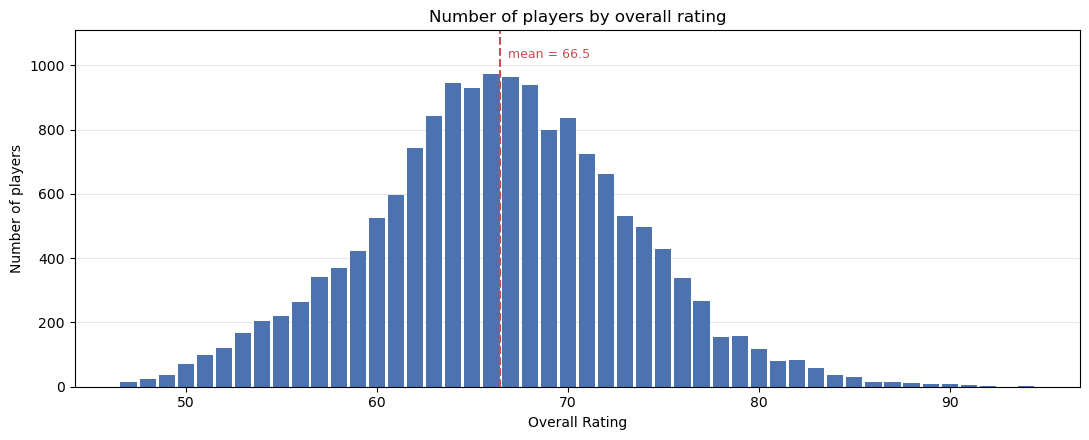

In [19]:
rating_ax, rating_summary = plot_distribution(
    players,
    by="overall_rating",
)

display(rating_summary)

### Examine the output
Look at where most players sit, how far the distribution reaches in each direction, and how quickly the counts fall away at the top end.

**Question:** What does this distribution tell you about how common highly rated players are? 

### Transition
The distribution tells us how rare high ratings are, but not the attributes of the players. A rating of 80 and a rating of 60 must differ in some way across the twenty-nine skill attributes. We now examine which skills actually separate them.

## 5. Which attributes differ most between highly rated and lower-rated players? 
**Question before running the code:** Which three or four skills do you expect to show the biggest difference between the best players and the rest?

Write them down now, along with your reasoning, before you look at the chart.

### Purpose of the code
`compare_attributes(...)` calculates the average of each skill attribute for every group of players and charts the difference between the highest and lowest group. Setting `group_by="rating_group"` compares players by how highly they are rated. Bars to the right show attributes where the highest-rated group scores *more* than the lowest-rated group. The returned table gives the group averages behind the chart.

rating_group,64 and under,65 to 69,70 to 74,75 and over,difference
balance,66.0,66.2,66.9,68.9,3.0
acceleration,66.5,68.3,69.1,71.6,5.1
sprint_speed,66.4,68.6,69.2,71.9,5.5
jumping,63.1,66.7,68.1,69.8,6.7
agility,63.3,67.0,68.7,71.3,8.1
strength,61.0,67.5,69.4,71.0,10.0
stamina,62.0,68.8,71.2,74.8,12.8
standing_tackle,47.2,52.4,55.8,60.7,13.6
heading_accuracy,51.4,57.6,61.9,65.7,14.2
marking,46.0,51.9,55.2,60.4,14.4


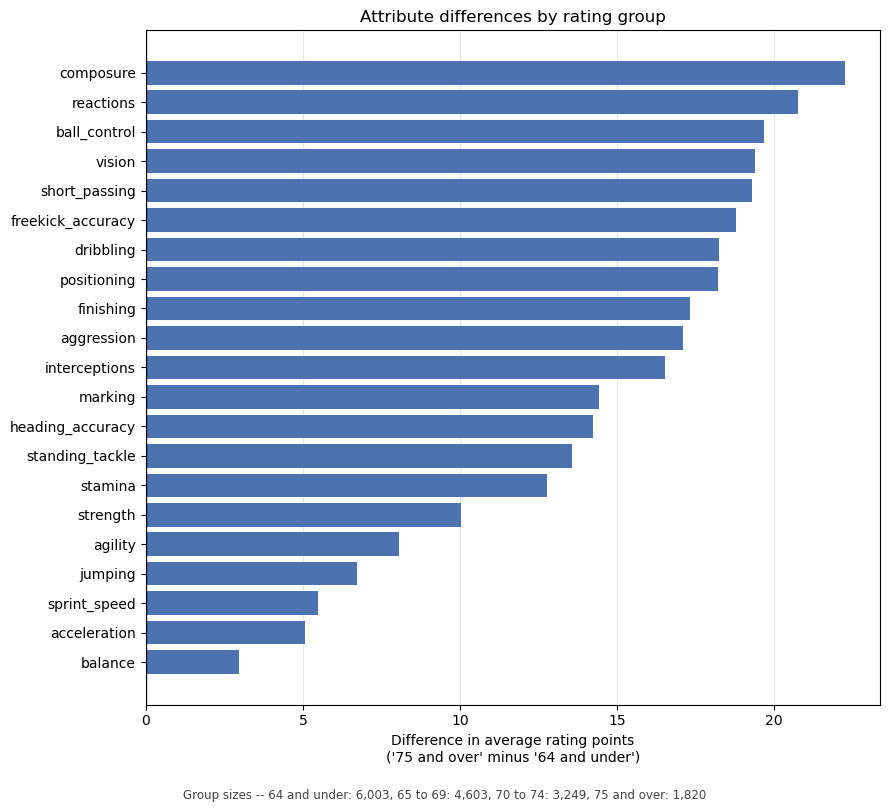

In [20]:
rating_attr_ax, rating_attr_table = compare_attributes(
    players,
    group_by="rating_group",
)

display(rating_attr_table)

### Examine the output
Start at the top and bottom of the chart, where the largest and smallest differences appear. Compare the result against the prediction you wrote down. 

**Question:** Which attributes most separate highly rated players from lower-rated players, and which barely separate them at all? 

Cite specific values as evidence. How does this compare with your prediction?

### Transition
We now know something about what a high rating is made of. But rating is not the only thing a manager sees on a player's profile, a players age could be related to both their mental and physical attribute ratings. Before we can ask how age matters, we need to know how ages are distributed in this dataset.

## 6. What is the distribution of age?
### Purpose of the code
The same helper function is used again. Only the setting `by` has changed, from`"overall_rating"` to `"age"`. Reusing a function with one changed setting is a common way to make two results directly comparable.

,age
players,15675.0
mean,25.4
standard deviation,4.6
minimum,17.0
median,25.0
maximum,40.0


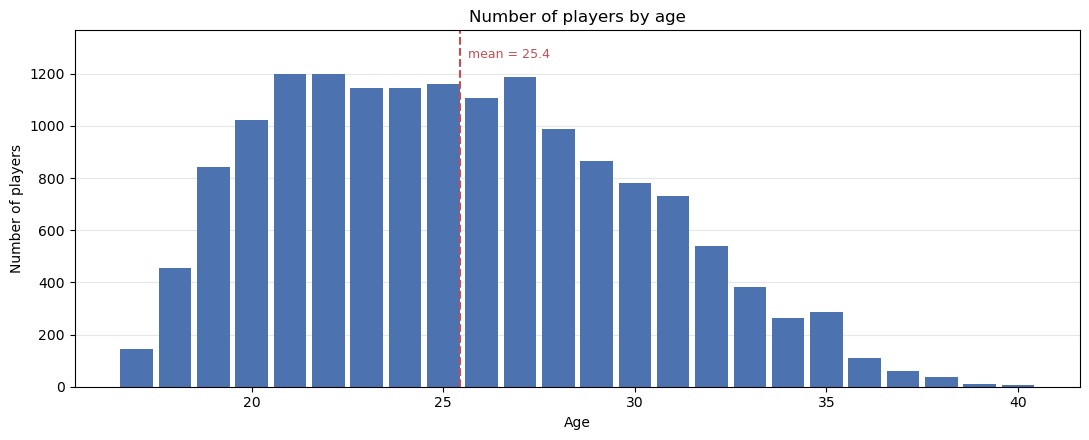

In [21]:
age_ax, age_summary = plot_distribution(
    players,
    by="age",
)

display(age_summary)

### Examine the output
Notice where the peak of the distribution sits and how the two tails differ from each other. Compare the shape of this distribution with the rating distribution you saw insection 4.

**Question:** How is age distributed among these players, and how does the shape differ from the rating distribution? What might explain the difference between the youngest and oldest ends? Cite specific values as evidence.

### Transition
We have looked at rating and age separately, but are they are related to each other?

## 7. How is age related to overall rating?
**Question before running the code:** Sketch or describe the shape you expect. At what age do you think average rating peaks, and what do you expect to happen after that? Write your prediction down before running the cell.
### Purpose of the code
`plot_by_age(...)` calculates the average of one column for each single year of age. Setting `value="overall_rating"` shows how average rating changes across a career. Ages represented by fewer than twenty-five players are left out, because a handful ofplayers is not enough to average reliably.

age,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38
average overall_rating,55.7,57.4,59.3,60.9,63.3,64.8,65.8,67.4,67.9,68.6,69.2,69.1,69.6,69.6,69.9,69.7,69.6,70.0,69.5,68.3,68.6,70.1


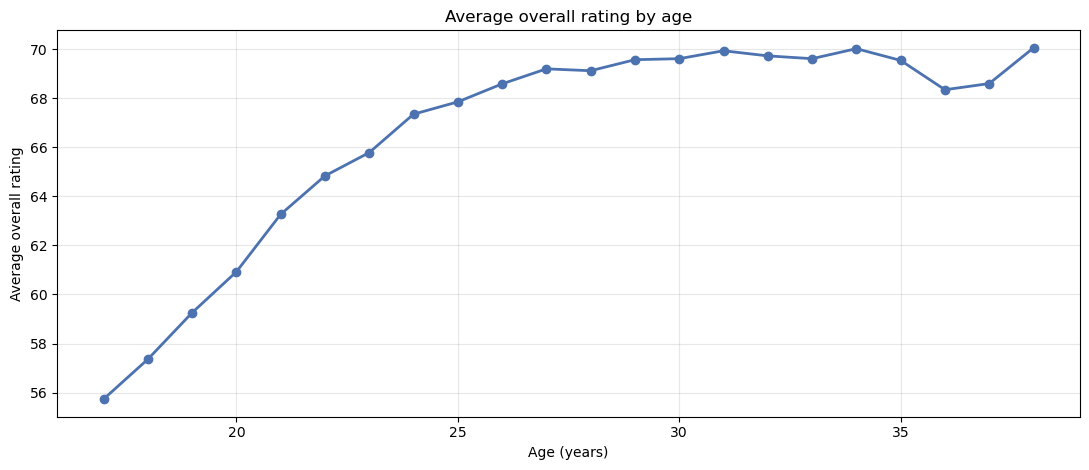

In [22]:
age_rating_ax, age_rating_table = plot_by_age(
    players,
    value="overall_rating",
)

display(age_rating_table.T)

### Examine the output
Trace the line from the youngest age to the oldest. Look carefully at what happens after the rise flattens out. Average rating climbs steeply through a player's early twenties and then flattens out. Taken at face value, this chart appears to say that players never decline. That should be suspicious. Soccer players do get slower as they age, so something about the data must be producing this shape. The explanation is **survivorship bias**. This file contains the players who were in the game in 2018-2019. Players who declined badly were released, retired, or dropped out of the leagues the game covers, so they are simply absent. The only old players we can see are the ones who were still good enough to remain.

**Question:** Explain in your own words why this chart cannot be read as a picture of individual careers. What kind of data would you need in order to see what actually happens to a player between ages 25 and 33?

### Transition
Survivorship bias makes the raw comparison between age groups untrustworthy: older players in this file are, on average, simply better players. If we want to ask whether age changes a player's *skills*, we have to compare older and younger players who are otherwise similar. The next section builds the grouping that makes that possible.

## 8. Comparing similar players: age groups and rating groups
To separate the effect of age from the effect of overall quality, we compare players **within the same rating group**. If two players are both rated 72, one aged 21 and one aged 31, then any difference in their skills cannot be explained by one of them simply being a better player. 

The preparation step added two labels to every player:

**Age groups:** 23 and under, 24 to 28, 29 and over. These roughly correspond to  players who are still developing, players in the middle of their careers, and players past the point where average rating stops climbing in the chart above.\
**Rating groups:** 64 and under, 65 to 69, 70 to 74, 75 and over. These are close to five rating points wide across most of the range, which is narrow so that players inside a group are comparable.

Arranged as a grid, **reading across a row compares players of different ages who have similar overall ratings**, and reading down a column compares players of different quality who are similar in age.
### Purpose of the code
`summarize_grid(...)` summarizes one column for every combination of age group and rating group. Setting `value="player_count"` shows how many players fall into each cell, so we can see which comparisons rest on enough evidence.

Age group,23 and under,24 to 28,29 and over
Rating group,,,
64 and under,3867,1441,695
65 to 69,1264,1927,1412
70 to 74,585,1420,1244
75 and over,293,801,726


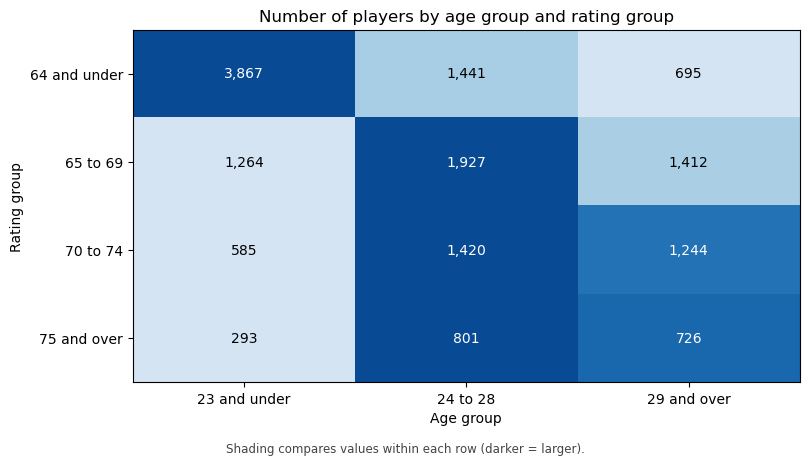

In [23]:
count_ax, count_grid = summarize_grid(
    players,
    value="player_count",
)

display(count_grid)

### Examine the output 
Look for the fullest and the emptiest cells. Notice that the players are not spread evenly, young players who are already highly rated and old players who are still lowly rated are both uncommon.

**Question:** Are the player evenly distributed across the age/rating groups? Cite specific counts.

### Purpose of the code
Before using the grid to compare skills, we should check that the grouping actually does what we want. This call changes `value` to `"overall_rating"`, which shows the average rating inside each cell. If the rating groups are doing their job, the numbers should stay roughly **flat as youread across a row**: players being compared across age should have close to the same overall rating.

Age group,23 and under,24 to 28,29 and over
Rating group,,,
64 and under,58.6,61.6,62.0
65 to 69,66.6,67.0,67.1
70 to 74,71.6,71.8,71.8
75 and over,77.4,78.1,78.3


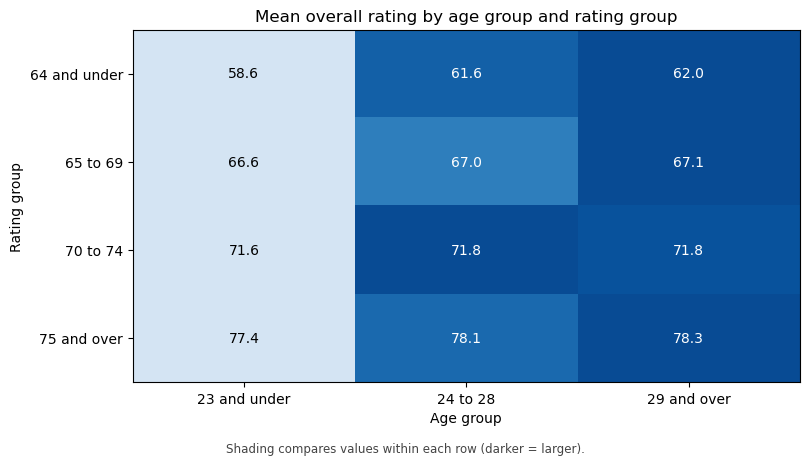

In [24]:
check_ax, check_grid = summarize_grid(
    players,
    value="overall_rating",
    statistic="mean",
)

display(check_grid)

### Examine the output
Read across each row and ask whether the average rating really is holding steady. Three of the four rows are flat to within a fraction of a rating point. One row is not. 

**Question:** Does our age normalization work, are cells within a row similar, why might a particular group behave differently from the others?

### Transition
We now have a way to compare older and younger players who are rated similarly. We can return to the skill attributes and ask whether age changes the kind of player someone is, rather than how good they are.

## 9. Do older players have different skill sets?
**Question before running the code:** Among players with the *same* overall rating, do you expect older and younger players to have the same skills? If not, which skills do you expect to favour each group?
### Purpose of the code
`compare_attributes(...)` returns, but with two changed settings. `group_by="age_group"`compares age groups instead of rating groups, and `within_rating="70 to 74"` restrictsthe comparison to players inside a single rating group, so that overall quality is held roughly constant. Bars to the right show skills where the oldest group scores higher; bars to the left show skills where the youngest group scores higher.

age_group,23 and under,24 to 28,29 and over,difference
acceleration,74.2,71.0,64.5,-9.7
sprint_speed,74.0,71.4,64.5,-9.5
agility,71.8,69.9,65.9,-5.9
dribbling,69.0,66.3,63.5,-5.5
balance,69.8,67.3,65.1,-4.6
ball_control,70.5,68.8,67.9,-2.6
finishing,55.1,54.9,54.1,-1.0
positioning,60.6,60.4,59.6,-1.0
stamina,71.0,72.5,69.9,-1.0
short_passing,69.0,68.0,68.0,-1.0


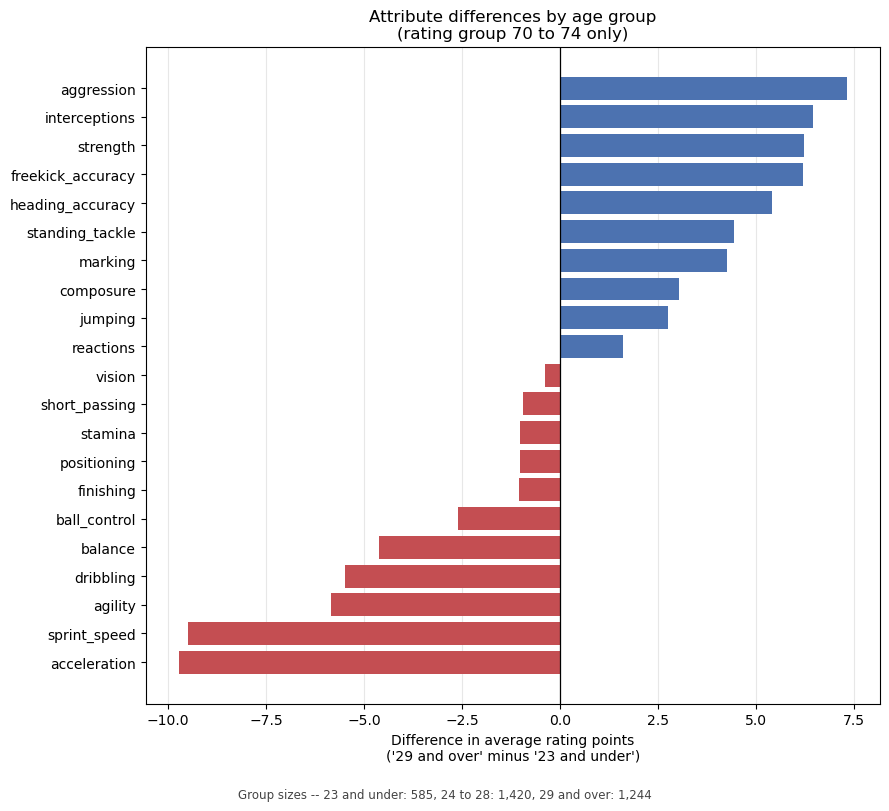

In [25]:
age_attr_ax, age_attr_table = compare_attributes(
    players,
    group_by="age_group",
    within_rating="70 to 74",
)

display(age_attr_table)

### Examine the output 
Look at both ends of the chart. Notice that the differences do not all point the same way: this is not a picture of one group being better, but of two groups being good at different things. Compare the list of skills that favour younger players with the list of skills that most separated highly rated players from the rest back in section 5. 

**Question:** Among players rated 70 to 74, how do the skill profiles of the youngest and oldest groups differ? Cite at least three attributes with specific values.

### Purpose of the code
A pattern found in one rating group might be a quirk of that group. This call changes`within_rating` to `"65 to 69"` and keeps every other setting the same, so the two results can be compared directly.

age_group,23 and under,24 to 28,29 and over,difference
acceleration,71.6,69.9,63.2,-8.4
sprint_speed,71.7,70.1,63.7,-8.0
dribbling,63.0,61.0,58.8,-4.3
agility,68.5,67.8,64.6,-4.0
balance,68.0,66.4,64.5,-3.5
ball_control,64.9,63.7,62.8,-2.1
finishing,50.1,50.0,49.5,-0.5
short_passing,63.6,63.0,63.2,-0.4
positioning,55.3,55.2,55.3,0.0
vision,55.7,55.2,56.2,0.4


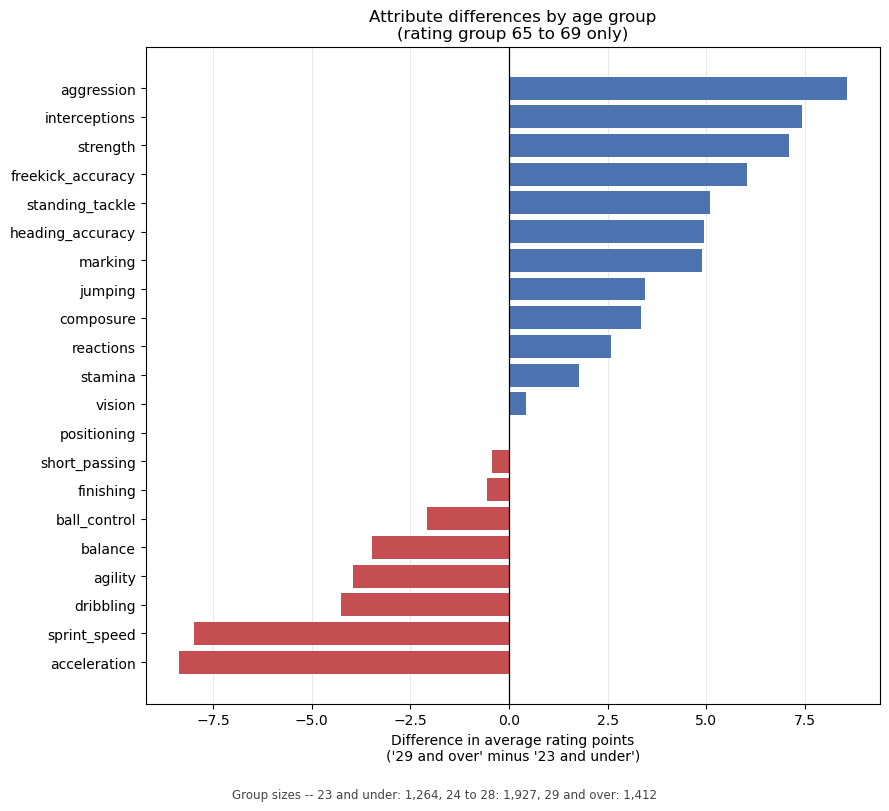

In [26]:
age_attr_ax_2, age_attr_table_2 = compare_attributes(
    players,
    group_by="age_group",
    within_rating="65 to 69",
)

display(age_attr_table_2)

### Compare the outputs
Compare the order of the attributes and the direction of the bars across the two charts. Look for skills that behave the same way in both, and any that do not.

**Question:** Does the pattern hold in a second rating group? Why does repeating the comparison in a different group make the finding more convincing than running it once? Cite evidence from both charts.

### Transition
We now know that older and younger players with the same rating are not the same player. That matters for a manager when deciding who to purchase. We turn to price.

## 10. Where should you spend your money?
### Purpose of the code
`summarize_grid(...)` returns, with `value="value_euro"` and `statistic="median"`. The median is used instead of the mean because a small number of superstars have enormous transfer values that would pull an average away from the typical player. Reading across a row now compares the price of players who are rated similarly but differ in age.

Age group,23 and under,24 to 28,29 and over
Rating group,,,
64 and under,280000.0,350000.0,240000.0
65 to 69,1100000.0,850000.0,575000.0
70 to 74,3900000.0,3200000.0,1900000.0
75 and over,12000000.0,10500000.0,7000000.0


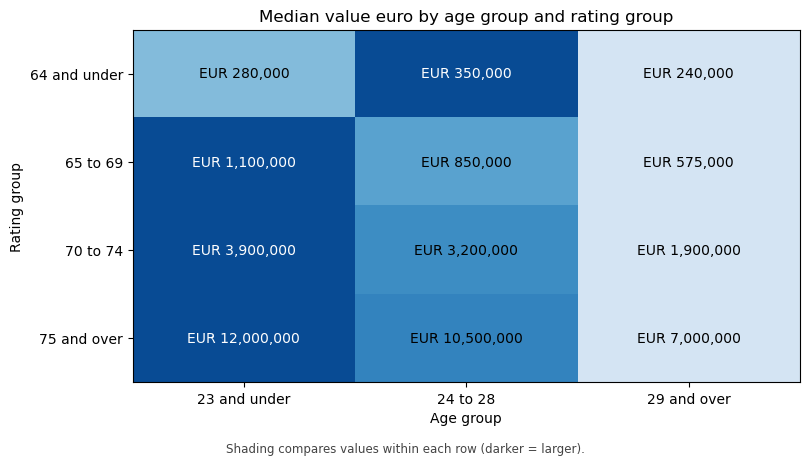

In [27]:
value_ax, value_grid = summarize_grid(
    players,
    value="value_euro",
    statistic="median",
    money=True,
)

display(value_grid)

### Examine the output
Read across each row and compare the price of the youngest and oldest groups at the same rating. Calculate the ratio for at least one row.

**Question:** At the same overall rating, how much more do younger players cost? Cite specific figures from at least two rows.

### Purpose of the code
Transfer value is not the only cost of a player. This call changes `value` to`"wage_euro"`, the weekly wage, and keeps every other setting the same.

Age group,23 and under,24 to 28,29 and over
Rating group,,,
64 and under,1000.0,2000.0,2000.0
65 to 69,4000.0,4000.0,4000.0
70 to 74,11000.0,11000.0,10000.0
75 and over,30000.0,35000.0,30000.0


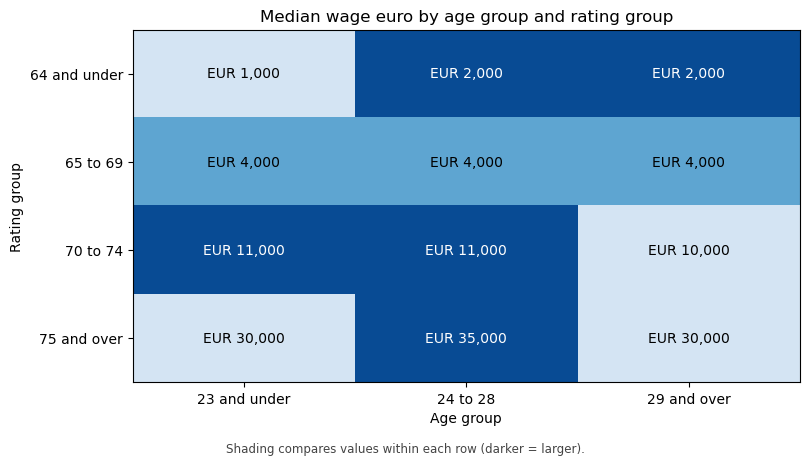

In [28]:
wage_ax, wage_grid = summarize_grid(
    players,
    value="wage_euro",
    statistic="median",
    money=True,
)

display(wage_grid)

### Compare the outputs
Compare the two grids carefully. Transfer value changes sharply across a row. Weekly wage does something quite different.

**Question:** How do the two kinds of cost behave differently across age? Why might a player who costs half as much to buy cost about the same amount every week? Cite figures from both grids.

Solutuion: 

### Transition
The price grids tell us what different players cost. The skill comparison in section tells us what those players are like. Putting the two together tells us what a manager is actually buying with the extra money.

### Purpose of the code
These two calls use `summarize_grid(...)` again, with `value` set to a skill attribute instead of a price. `sprint_speed` was one of the attributes that most favoured younger players in section 9; `interceptions` was one that most favoured older players. Comparing these grids against the value grid shows what changes alongside the price.

Age group,23 and under,24 to 28,29 and over
Rating group,,,
64 and under,67.0,67.9,59.9
65 to 69,71.7,70.1,63.7
70 to 74,74.0,71.4,64.5
75 and over,77.5,73.9,67.4


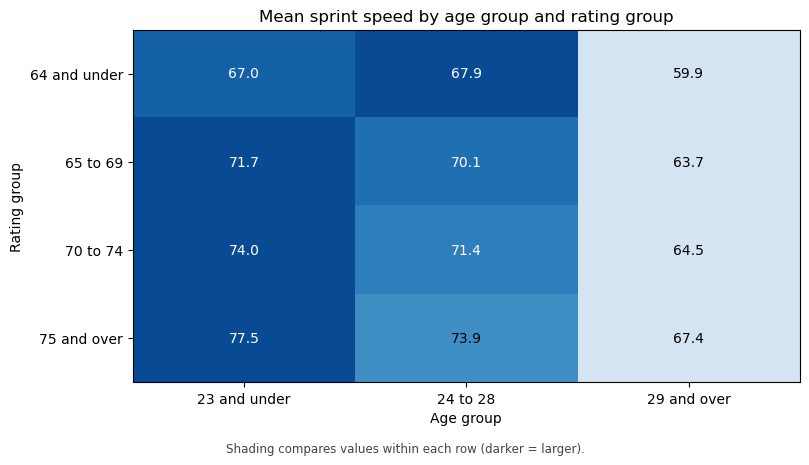

In [29]:
speed_ax, speed_grid = summarize_grid(
    players,
    value="sprint_speed",
    statistic="mean",
)

display(speed_grid)

Age group,23 and under,24 to 28,29 and over
Rating group,,,
64 and under,41.5,47.3,52.3
65 to 69,47.9,50.6,55.3
70 to 74,51.9,54.7,58.3
75 and over,57.7,60.2,62.3


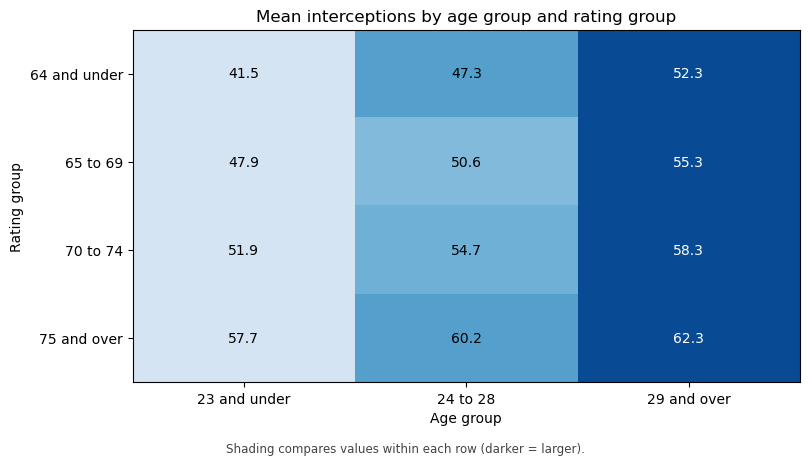

In [30]:
interceptions_ax, interceptions_grid = summarize_grid(
    players,
    value="interceptions",
    statistic="mean",
)

display(interceptions_grid)

### Compare the outputs
Line up all three grids: value, sprint speed, and interceptions. Follow a single row across each one.

**Question:** Along a single row of the grid, what does the extra money buy, and what does it give up? Cite figures from all three grids. 

A word of caution before you conclude that speed is what costs money. Age changes along each row as well, and so does everything else that comes with age. From these grids alone you cannot tell whether managers are paying for pace itself or paying for youth, which happens to come with pace attached. Separating those two explanations would need a comparison that holds age constant as well as rating.

### Transition
You now have evidence about what separates highly rated players, how older and younger players differ at the same rating, what each type costs to buy, what each costs in wages, and what changes in skill accompanies the price difference. The final step is toturn that evidence into a strategy.

## 11. Develop an evidence-based insight
**Assignment question:** You have a fixed budget and you want a competitive team. What **type** of player would you spend your money on, and why? Support your strategy with at least three pieces of evidence from this investigation, and be specific about what your team would be good at and what it would struggle with. Prepare a concise response with:

**Question investigated**\
**Evidence examined**\
**Strategy: what type of player you would buy**\
**Your team's likely strengths**\
**Your team's likely weaknesses**\
**Additional information you would need before committing the budget**

There is no single correct strategy. Two things worth remembering as you write. First, nothing in this dataset says which attributes win more matches, so any claim about which squad would actually perform better goes beyond the evidence. Second, these are ratings assigned by a videogame, so your conclusions apply to decisions inside that game.


# Return to your own questions
The shared investigation illustrates how to move from a mission to questions, evidence, interpretation, possible implications, and limitations. It also shows a habit worth carrying forward: when a pattern looks surprising, the first question to ask is whether the comparison is fair. Return to the questions you developed at the beginning. You may now investigate one of them, revise or combine questions, or develop a new question suggested by the guidedwork. Use the provided helper functions and adjust their settings to gather evidence. 

Some settings you have not used yet:

`plot_by_age(players, value="sprint_speed")` traces any attribute across age\
`plot_by_age(players, value="overall_rating", compare="rating_group")` draws a  separate line for each rating group\
`compare_attributes(players, group_by="rating_group", within_age="29 and over")`  compares rating groups inside a single age group\
`summarize_grid(players, value="composure")` works with any of the twenty-nine  attributes>

**Your exploration:** What question or questions will you investigate? What evidence will you examine, what observations and insights do you develop, and what limitations affect your conclusions?